In [2]:
# 1. Chargement des données
# On s'assure que 'Date' est l'index et est au format datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('raw_financial_data.csv', index_col='Date', parse_dates=True)

In [3]:
print(f"Dimensions initiales: {df.shape}")

Dimensions initiales: (1827, 10)


In [4]:
# 2. Alignement temporel : étape critique
# On ne garde que les jours où le S&P 500 (^GSPC) a coté (jours ouvrés),
# pour comparer actions et cryptos sur les mêmes fenêtres.
df_clean = df.dropna(subset=['^GSPC'])

In [5]:
# 3. Gestion des valeurs manquantes (forward fill)
# ffill : report de la dernière valeur connue.
df_clean = df_clean.ffill()

In [6]:
# 4. Calcul des rendements logarithmiques
# Formule : ln(Prix_t / Prix_t-1)
# Rendements log : normalisés et additifs.
df_returns = np.log(df_clean / df_clean.shift(1)).dropna()

In [7]:
# 5. Feature engineering : volatilité roulante (20 jours)
# Ajout de deux indicateurs de risque en vue du dashboard Power BI.
df_returns['BTC_Vol_20d'] = df_returns['BTC-USD'].rolling(window=20).std()
df_returns['NVDA_Vol_20d'] = df_returns['NVDA'].rolling(window=20).std()

In [8]:
# 6. Enregistrement du fichier propre
# Sauvegarde pour l'étape suivante (analyse statistique).
df_returns.to_csv('processed_financial_data.csv')

print("\n--- NETTOYAGE TERMINÉ ---")
print(f"Dimensions finales (après calcul des rendements) : {df_returns.shape}")
print(df_returns.head())


--- NETTOYAGE TERMINÉ ---
Dimensions finales (après calcul des rendements) : (1255, 12)
                AAPL      AMZN   BTC-USD   ETH-USD     GOOGL      META  \
Date                                                                     
2021-03-23 -0.006913  0.008524  0.003840 -0.007528  0.005226 -0.009963   
2021-03-24 -0.020196 -0.016204 -0.036552 -0.052111 -0.004320 -0.029647   
2021-03-25  0.004155 -0.013308 -0.020485  0.001220 -0.000035 -0.012124   
2021-03-26  0.005128  0.001892  0.064288  0.065200 -0.003810  0.015238   
2021-03-29  0.001484  0.007735  0.046300  0.066365  0.010348  0.027187   

                MSFT      NVDA      TSLA     ^GSPC  BTC_Vol_20d  NVDA_Vol_20d  
Date                                                                           
2021-03-23  0.006715 -0.008798 -0.011770 -0.007660          NaN           NaN  
2021-03-24 -0.008963 -0.033273 -0.049359 -0.005482          NaN           NaN  
2021-03-25 -0.013339 -0.008559  0.015929  0.005227          NaN         

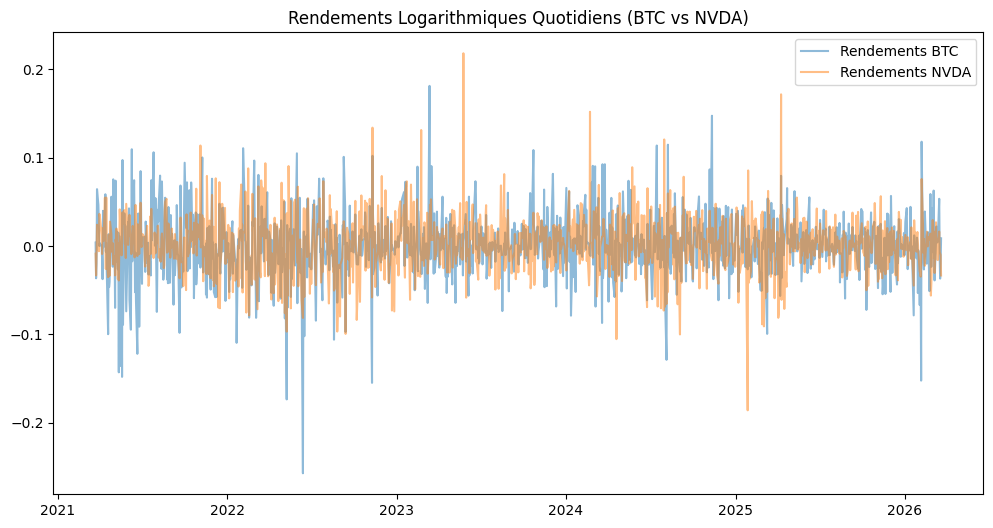

In [9]:
# 7. Visualisation de contrôle
# On affiche les rendements (ça doit ressembler à du "bruit" autour de 0).
plt.figure(figsize=(12,6))
plt.plot(df_returns['BTC-USD'], label='Rendements BTC', alpha=0.5)
plt.plot(df_returns['NVDA'], label='Rendements NVDA', alpha=0.5)
plt.title("Rendements Logarithmiques Quotidiens (BTC vs NVDA)")
plt.legend()
plt.show()

In [10]:
import seaborn as sns

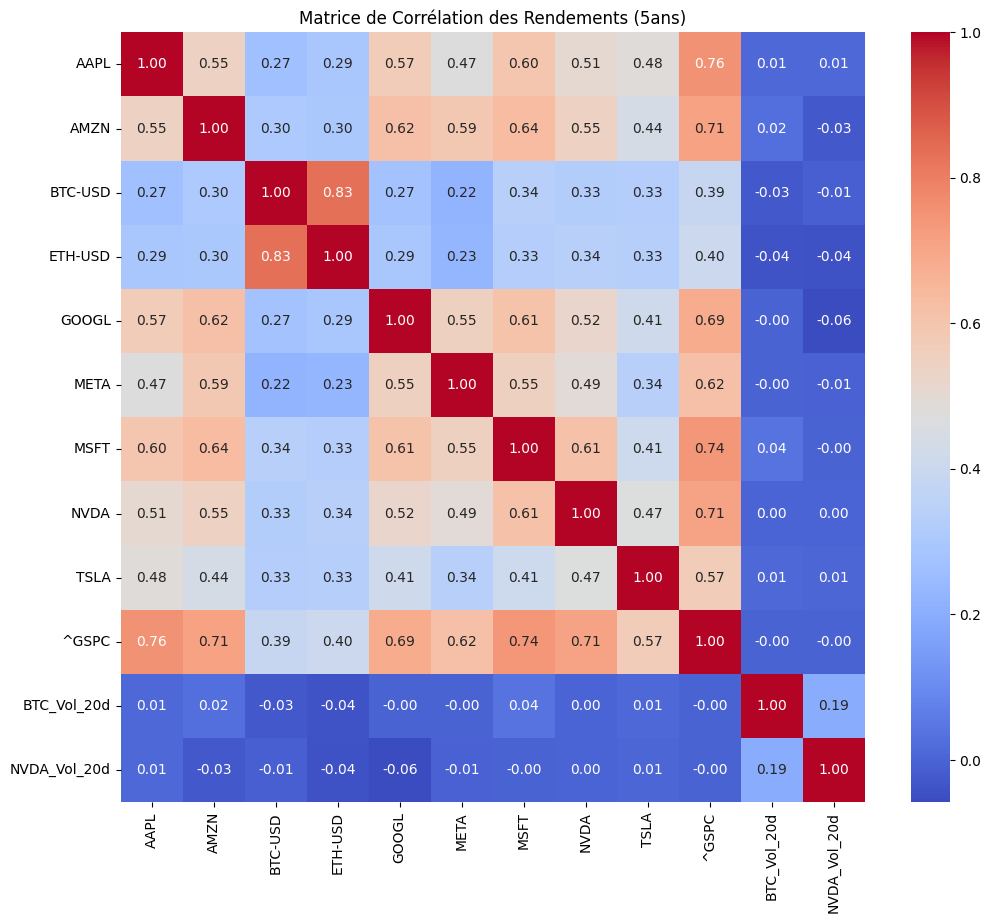

In [11]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_returns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des Rendements (5ans)")
plt.show()

In [12]:
# Analyse de la matrice
# Corrélation forte entre BTC-USD & ETH-USD ce qui est logique car crypto est marché homogène
# Corrélation forte entre Big Tech et S&P500 car elles pèsent lourds dans l'indice américain
# Crypto et Actions ne se suivent pas aveuglément

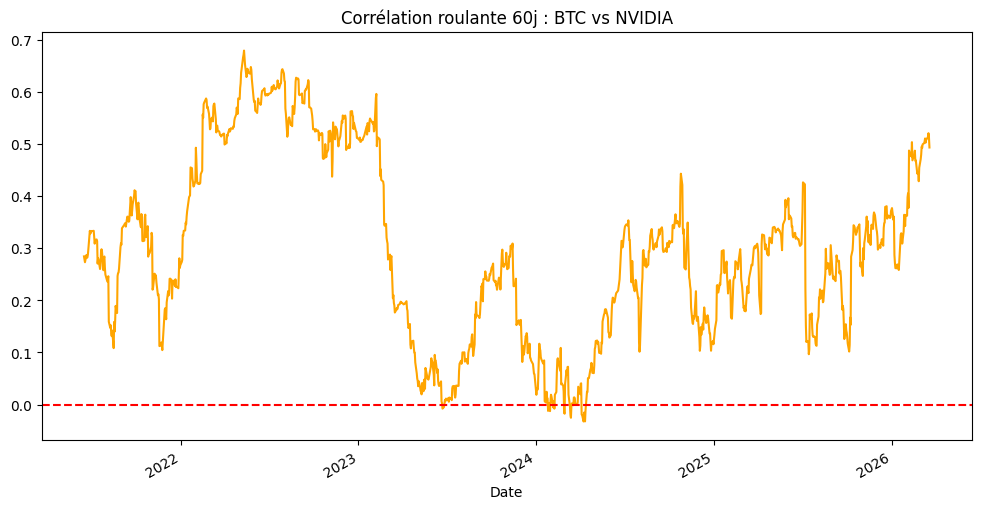

In [13]:
rolling_corr = df_returns['BTC-USD'].rolling(60).corr(df_returns['NVDA'])
rolling_corr.plot(figsize=(12,6), color='orange')
plt.title("Corrélation roulante 60j : BTC vs NVIDIA")
plt.axhline(y=0, color='r', linestyle='--') # Ligne neutre
plt.show()

In [14]:
# Analyse de la corrélation roulante
# La ligne de flottaison 0.0 montre que le BTC et NVIDIA ont tendance à bouger dans le même sens, à part 2024
# Pics de corrélation forte mi-2022 et début 2026, soit euphorie soit vent de panique où les actifs sont vendus ou achetés en même temps sans distinction.
# Creux (découplage proche de 0), à ce moment là l'un peut s'envoler et l'autre dégringoler ou inversement
# Tendance début 2026: BTC & NVIDIA à nouveau meilleurs amis mais prendre garde.

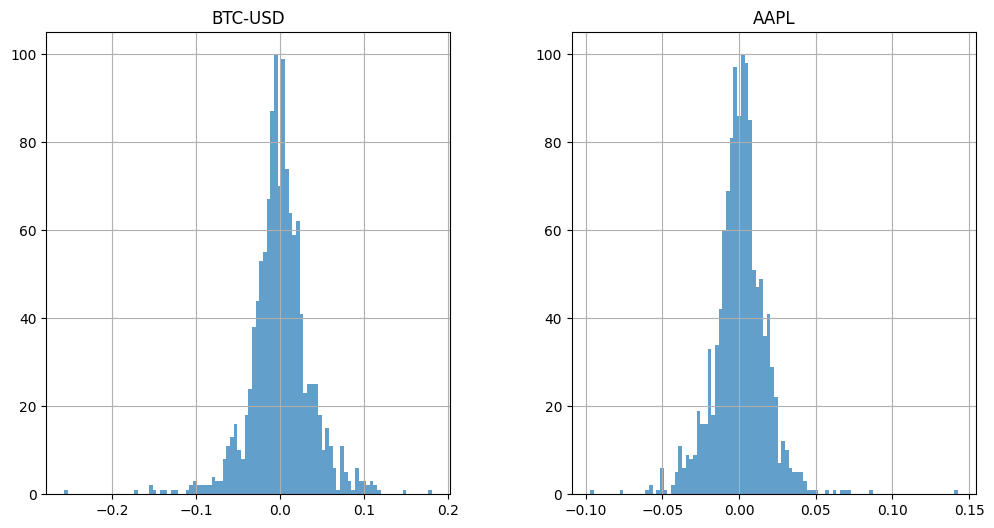

In [15]:
df_returns[['BTC-USD', 'AAPL']].hist(bins=100, figsize=(12,6), alpha=0.7)
plt.show()

In [16]:
# Analyse de ces deux histogrammes
# BTC-USD est beaucoup plus volatile (-20 à 20%) en une journée qu'est AAPL. 
# Sommet (Moyenne) proche de 0.0 pour les deux donc rendement proche de zéro
# Attention au "risque de queue" (fat tails)

In [17]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_returns['BTC-USD'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}') # Si p-value < 0.05, c'est stationnaire !

ADF Statistic: -36.36215171050885
p-value: 0.0


In [18]:
# Interprétation de ADF:
# PLus il est négatif plus il est probable que la série soit stationnaire. 
# Interprétation de p-value
# p-value est quasi proche de 0.0 donc on rejette l'hypothèse de non-stationnarité.

In [19]:
import statsmodels.api as sm
import seaborn as sns

In [20]:
# On définit Y (cible) et X (prédicteurs)
Y = df_returns['BTC-USD']
X = df_returns[['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', '^GSPC']]
X = sm.add_constant(X) # Ajoute l'intercept (la constante)

model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                BTC-USD   R-squared:                       0.179
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     34.05
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           7.56e-49
Time:                        12:14:03   Log-Likelihood:                 2521.3
No. Observations:                1255   AIC:                            -5025.
Df Residuals:                    1246   BIC:                            -4978.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0003      0.001     -0.319      0.7

In [21]:
# Interprétation des résultats
# R-squared= les variations des 8 actions expliquent ~18% des mouvements du Bitcoin, c'est peu et beaucoup pour la finance, ce qui prouve que le BTC est devenu un actif macro lié à la tech
# p-value= TSLA & ^GSPC influencent statistiquement beaucoup (MSFT aussi), GOOGL n'a pas d'impact
# coef= ^GSPC (0.81); si SP500 monte de 1% alors le BTC monte de .81% (effet levier), quant à AAPL (-.16) qui signifie que l'un et l'autre peuvent bouger à l'inverse.
# Kurtosis= 6.66 quand une distribution normale a un Kurt de 3 ce qui signifie qu'il y a beaucoup d'événements extrêmes que ce que la théorie prévoit.
# Synthèse= surveiller SP500 & Tesla mais ignorer Google & Amazon quant à la corrélation avec BTC

In [22]:
from statsmodels.tsa.stattools import grangercausalitytests

In [23]:
# On teste sur 5 jours de décalage (lags)
print("--- Test : Est-ce que NVDA cause BTC ? ---")
gc_res = grangercausalitytests(df_returns[['BTC-USD', 'NVDA']], maxlag=5)

--- Test : Est-ce que NVDA cause BTC ? ---

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2103  , p=0.6466  , df_denom=1251, df_num=1
ssr based chi2 test:   chi2=0.2108  , p=0.6461  , df=1
likelihood ratio test: chi2=0.2108  , p=0.6462  , df=1
parameter F test:         F=0.2103  , p=0.6466  , df_denom=1251, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.9381  , p=0.3916  , df_denom=1248, df_num=2
ssr based chi2 test:   chi2=1.8838  , p=0.3899  , df=2
likelihood ratio test: chi2=1.8824  , p=0.3902  , df=2
parameter F test:         F=0.9381  , p=0.3916  , df_denom=1248, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9859  , p=0.3985  , df_denom=1245, df_num=3
ssr based chi2 test:   chi2=2.9744  , p=0.3956  , df=3
likelihood ratio test: chi2=2.9709  , p=0.3961  , df=3
parameter F test:         F=0.9859  , p=0.3985  , df_denom=1245, df_num=3

Granger Causality
number of lags (no zero) 4

In [24]:
# Interprétation des résultats du test de causalité de Granger
# Toutes les p-values > 0.05 donc NVIDIA ne 'cause' pas le BTC, ce qui s'est passé hier jusqu'à cinq jours avant n'aide pas à prédire ce que le BTC fera demain.
# Logique car l'information circule instantanément: si une nouvelle tombe sur l'IA ou le marché, les deux réagissent le même jour.

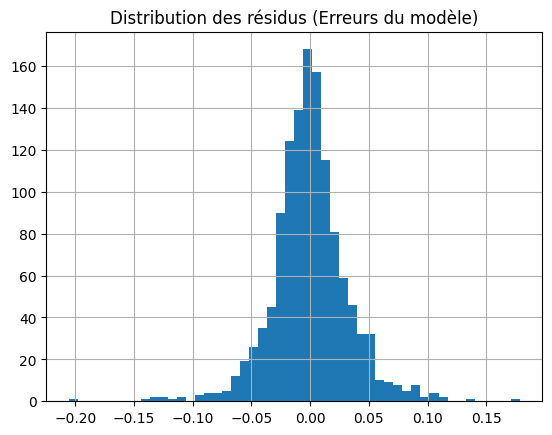

In [25]:
model.resid.hist(bins=50)
plt.title("Distribution des résidus (Erreurs du modèle)")
plt.show()

In [26]:
# Interprétation de l'analyse de résidus
# Montre la différence entre ce que le modèle a prédit pour BTC et ce qui s'est réellement passé
# Erreur centrée sur 0 donc non biaisé, prédictions plus ou moins correctes.
# Dispersion des erreurs entre -0.05 et +0.05 ce qui signifie que le modèle (basé sur les 7 mercenaires & SP500) arrive à suivre le BTC à 5% près.
# Outliers vers -0.20 et +0.15 là où le BTC fait un mouvement massif et que les actions n'ont pas suivi -> modèle totalement à la traîne face aux événements spécifiques à la crypto (tweet de Musk, régulation, hack, etc)

In [27]:
# 1. Préparation des Features
# Création d'un nouveau DataFrame de 'profils'
active_profiles = pd.DataFrame({
    'Return': df_returns.mean()*252,
    'Volatility': df_returns.std()*np.sqrt(252)
})
print(active_profiles)

                Return  Volatility
AAPL          0.145455    0.273541
AMZN          0.055799    0.352105
BTC-USD       0.051644    0.568965
ETH-USD       0.047854    0.764252
GOOGL         0.219861    0.306523
META          0.142989    0.439392
MSFT          0.104931    0.261396
NVDA          0.517031    0.512624
TSLA          0.100260    0.589214
^GSPC         0.100693    0.168224
BTC_Vol_20d   8.493619    0.196217
NVDA_Vol_20d  7.705389    0.172160


In [28]:
# Interprétation des rendements VS volatilité
# NVIDIA rapporte 10 fois plus que BTC pour une volatilité quasiment identique (bien meilleur couple rendement/risque)
# BTC est 3 fois plus risqué que le marché boursier global
# NVIDIA a un rendement annuel moyen de 51.7% sur la période

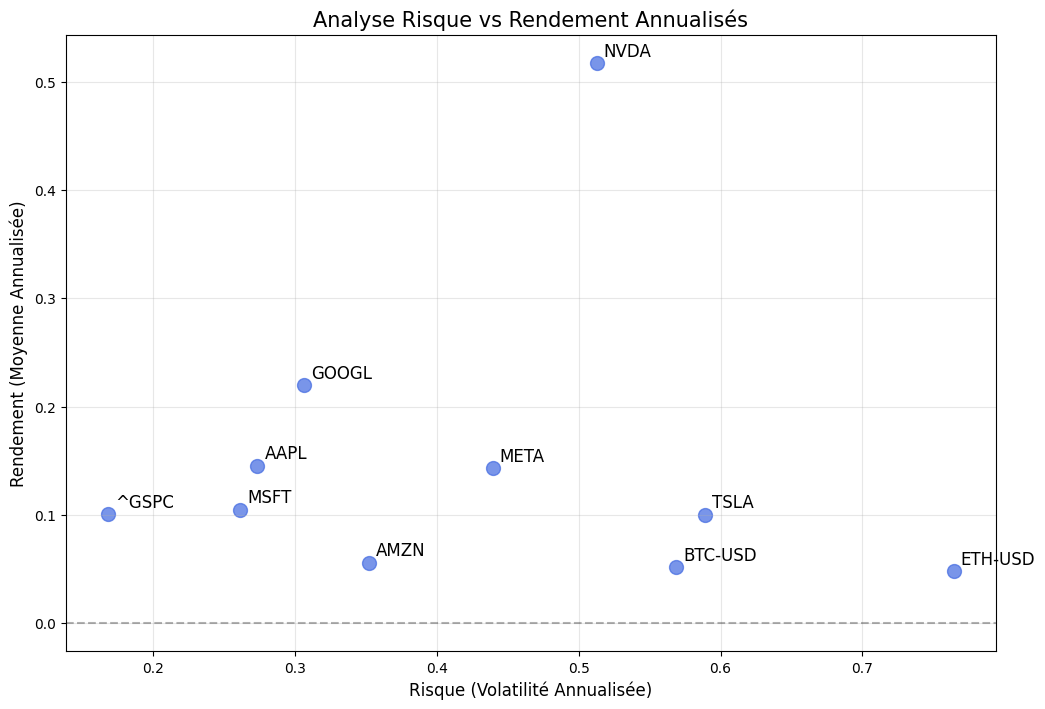

In [29]:
# Graphique Risque / Rendement
# 1. On filtre pour ne garder que les vrais actifs (on enlève les colonnes de Vol_20d)
assets_only = active_profiles.drop(['BTC_Vol_20d', 'NVDA_Vol_20d'])

# 2. Création du graphique
plt.figure(figsize=(12, 8))
plt.scatter(assets_only['Volatility'], assets_only['Return'], alpha=0.7, s=100, c='royalblue')

# 3. Ajout des noms des actifs à côté des points
for i, txt in enumerate(assets_only.index):
    plt.annotate(txt, (assets_only['Volatility'].iloc[i], assets_only['Return'].iloc[i]), 
                 xytext=(5,5), textcoords='offset points', fontsize=12)

# 4. Habillage du graphique
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title("Analyse Risque vs Rendement Annualisés", fontsize=15)
plt.xlabel("Risque (Volatilité Annualisée)", fontsize=12)
plt.ylabel("Rendement (Moyenne Annualisée)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
# Interprétation du graphique
# Champion: NVDA avec un rendement élevé pour un risque moyen (par rapport au BTC)
# Sage: ^GSPC avec un petit rendement pour le risque le plus faible
# Téméraire: BTC-USD avec le risque le plus élevé pour un rendement moyen et plus faible qu'AAPL & MSFT
# OVNI: ETH-USD avec une volatilité de >70%

In [31]:
# 2. Standardisation (Scaling)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
scaled_features = scaler.fit_transform(active_profiles)

In [32]:
# 3. Application du K-Means
# random_state fixé pour la reproductibilité
kmeans = KMeans(n_clusters=3, random_state=42)
active_profiles['Cluster'] = kmeans.fit_predict(scaled_features)

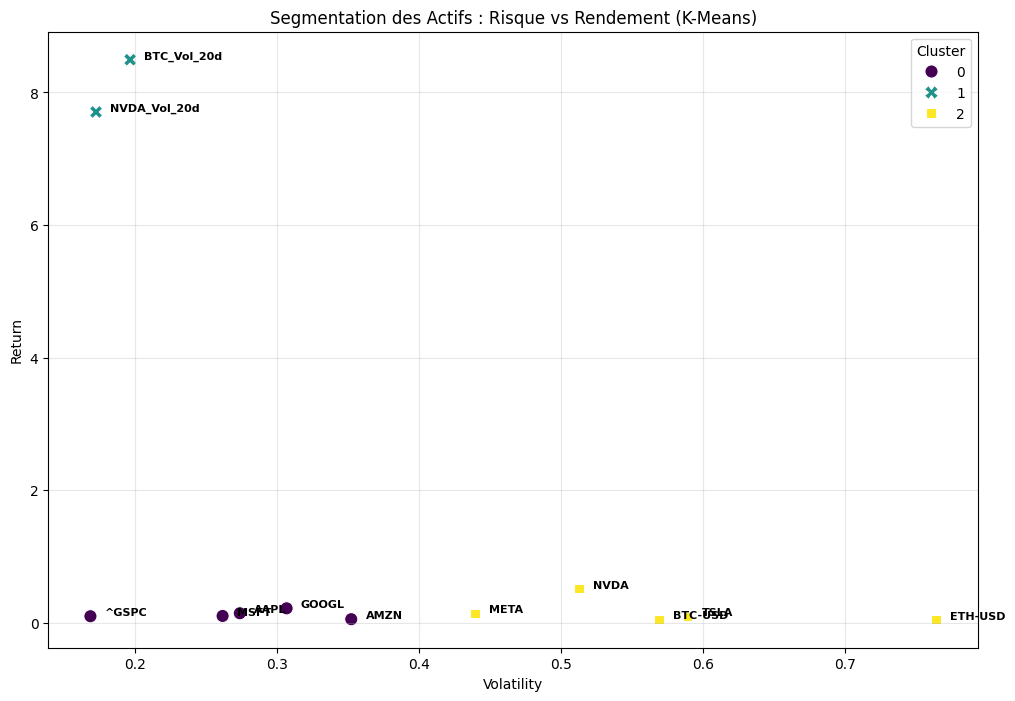

In [33]:
# 4. Modélisation des données
# Visualisation des Clusters (graphique de segmentation)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=active_profiles, x='Volatility', y='Return', 
                hue='Cluster', style='Cluster', s=90, palette='viridis')

# On ajoute le nom des tickers sur le graph
for i in range(active_profiles.shape[0]):
    plt.text(active_profiles.Volatility.iloc[i] + 0.01, 
             active_profiles.Return.iloc[i] +0.01, 
             active_profiles.index[i], 
             fontsize=8,
             weight='semibold')

plt.title("Segmentation des Actifs : Risque vs Rendement (K-Means)")
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
# Interprétation du graphique de segmentation en 3 clusters
# Cluster 1 (croix vertes): indicateurs de volatilité, ils n'ont rien à faire là
# Cluster 2 (ronds violets): actifs 'prudents', faible volatilité et faible rendement avec ^GSPC, AAPL, MSFT, GOOGL & AMZN
# Cluster 3 (carrés jaunes): actifs 'agressifs', forte volatilité et rendements +/- idem avec META, NVDA, BTC, TSLA & ETH

In [35]:
# ML - Classification avec RF
# 1 - Définir la cible : 1 si le marché monte le lendemain, 0 sinon
# Création de la target : 1 si positif, sinon 0
df_returns['Target_BTC'] = (df_returns['BTC-USD'].shift(-1) > 0).astype(int)

# Suppression de la dernière ligne qui n'a pas de 'demain'
df_ml = df_returns.dropna()

In [36]:
df_ml['Target_BTC'].value_counts(normalize=True)

Target_BTC
0    0.503236
1    0.496764
Name: proportion, dtype: float64

In [37]:
# Sélection des prédicteurs (features)
features = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', '^GSPC', 'BTC-USD', 'ETH-USD']
X = df_ml[features]
y = df_ml['Target_BTC']

In [38]:
# Split Train/Test
# Ne pas mélanger les données au hasard car chronologique (shuffle=False)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# On répartit les données en ensemble d'apprentissage et de validation en 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [39]:
# Entraînement & évaluation
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("--- Rapport de Performance ---")
print(classification_report(y_test, y_pred))

--- Rapport de Performance ---
              precision    recall  f1-score   support

           0       0.51      0.54      0.52       126
           1       0.49      0.46      0.47       122

    accuracy                           0.50       248
   macro avg       0.50      0.50      0.50       248
weighted avg       0.50      0.50      0.50       248



In [40]:
# Interprétation du modèle
# Métriques clés :
#   - accuracy à 50% : le modèle est aussi performant qu'un pile ou face...
#   - précision (classe 1) : 0.49, quand le modèle prédit que BTC va monter il se trompe plus d'une fois sur deux.
#   - recall (classe 1) : 0.46, le modèle ne réussit à capter que 46% des vraies hausses du marché.
# Confusion du modèle : scores quasi identiques, donc aucun motif (pattern) réel dans les données pour prédire BTC avec certitude.
# Explications : manque d'indicateurs (RSI, moyennes mobiles, etc), efficience du marché

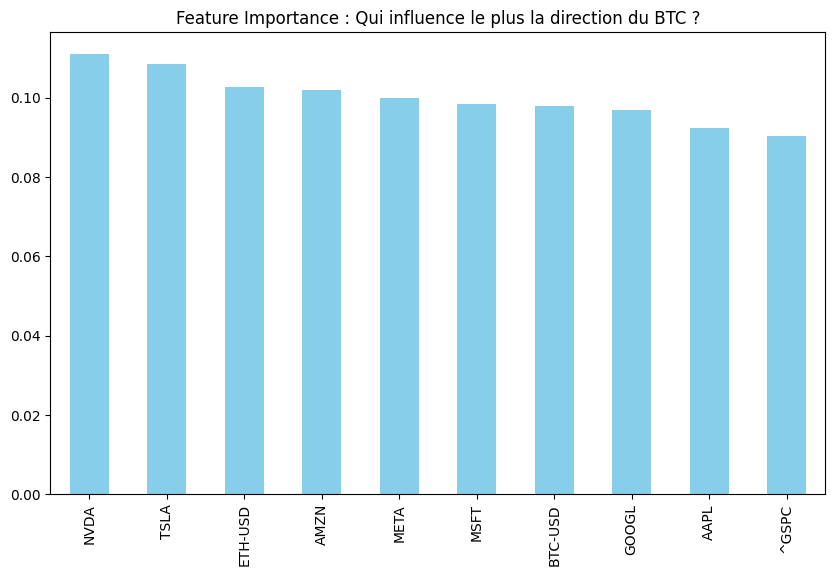

In [41]:
# L'importance des variables
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.plot(kind='bar', color='skyblue')
plt.title("Feature Importance : Qui influence le plus la direction du BTC ?")
plt.show()

In [42]:
# Interprétation du graphique:
# NVDA & TSLA sont les variables les plus fortes ~11%, logique car les plus volatiles et spéculatives du secteur tech souvent corrélées au sentiment de risque des investisseurs crypto
# ETH-USD en troisième va souvent de paire avec BTC-USD
# ^GSPC dernière ce qui signifie que pour le modèle établi, le marché boursier global est un moins bon indicateur du BTC que les actions tech spécifiques
# Conclusion: le modèle hésite, aucune variable ne se détache ce qui explique le score de 0.50, rien de solide pour prédire le futur avec certitude.

In [43]:
# Création du DataFrame d'importance
importances = rf_model.feature_importances_
features = X.columns
df_importance = pd.DataFrame({'Variable': features, 'Importance': importances})

# Export en CSV
df_importance.to_csv('importance_rf.csv', index=False)